In [122]:
import pandas as pd
from sklearn.metrics import r2_score as R2_score
import numpy as np
import seaborn as sns

## Carga de datos, exploración y preparación de los datos para creación del modelo en Store1

In [123]:
data_stores=pd.read_csv("./Rossmann/store.csv", index_col="Store")
data_stores.head(5)

,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
Store,,,,,,,,,
1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [124]:
data_stores.shape

(1115, 9)

In [125]:
data_stores.describe().T

,count,mean,std,min,25%,50%,75%,max
CompetitionDistance,1112.0,5404.901079,7663.174720,20.0,717.5,2325.0,6882.5,75860.0
CompetitionOpenSinceMonth,761.0,7.224704,3.212348,1.0,4.0,8.0,10.0,12.0
CompetitionOpenSinceYear,761.0,2008.668857,6.195983,1900.0,2006.0,2010.0,2013.0,2015.0
Promo2,1115.0,0.512108,0.500078,0.0,0.0,1.0,1.0,1.0
Promo2SinceWeek,571.0,23.595447,14.141984,1.0,13.0,22.0,37.0,50.0
Promo2SinceYear,571.0,2011.763573,1.674935,2009.0,2011.0,2012.0,2013.0,2015.0


In [126]:
data_stores.info()

<class 'pandas.DataFrame'>
RangeIndex: 1115 entries, 1 to 1115
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StoreType                  1115 non-null   str    
 1   Assortment                 1115 non-null   str    
 2   CompetitionDistance        1112 non-null   float64
 3   CompetitionOpenSinceMonth  761 non-null    float64
 4   CompetitionOpenSinceYear   761 non-null    float64
 5   Promo2                     1115 non-null   int64  
 6   Promo2SinceWeek            571 non-null    float64
 7   Promo2SinceYear            571 non-null    float64
 8   PromoInterval              571 non-null    str    
dtypes: float64(5), int64(1), str(3)
memory usage: 89.3 KB


In [127]:
data_todas_tiendas = pd.read_csv("./Rossmann/train.csv", parse_dates=["Date"])
data_todas_tiendas

C:\Users\CHOPPE\AppData\Local\Temp\ipykernel_25816\1671087955.py:1: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  data_todas_tiendas = pd.read_csv("./Rossmann/train.csv", parse_dates=["Date"])


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Id
0,1,5,2015-07-17,4852,519,1,1,0,0,303445
1,2,5,2015-07-17,4518,495,1,1,0,1,959585
2,3,5,2015-07-17,6679,673,1,1,0,1,739744
3,4,5,2015-07-17,10514,1343,1,1,0,1,864001
4,5,5,2015-07-17,4355,513,1,1,0,1,981931
...,...,...,...,...,...,...,...,...,...,...
1001594,1111,2,2013-01-01,0,0,0,0,a,1,225066
1001595,1112,2,2013-01-01,0,0,0,0,a,1,775592
1001596,1113,2,2013-01-01,0,0,0,0,a,1,135205
1001597,1114,2,2013-01-01,0,0,0,0,a,1,954751


In [128]:
store=1
data_store_1=data_todas_tiendas[data_todas_tiendas["Store"]==1].sort_values(by="Date", ascending=True)
data_store_1

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Id
1000485,1,2,2013-01-01,0,0,0,0,a,1,690197
999370,1,3,2013-01-02,5530,668,1,0,0,1,988300
998255,1,4,2013-01-03,4327,578,1,0,0,1,919910
997140,1,5,2013-01-04,4486,619,1,0,0,1,662609
996025,1,6,2013-01-05,4997,635,1,0,0,1,1008092
...,...,...,...,...,...,...,...,...,...,...
4460,1,1,2015-07-13,5054,553,1,1,0,0,308477
3345,1,2,2015-07-14,5042,544,1,1,0,0,704685
2230,1,3,2015-07-15,4767,550,1,1,0,0,64663
1115,1,4,2015-07-16,4427,517,1,1,0,0,324709


In [129]:
data_store_1.info()

<class 'pandas.DataFrame'>
Index: 928 entries, 1000485 to 0
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Store          928 non-null    int64         
 1   DayOfWeek      928 non-null    int64         
 2   Date           928 non-null    datetime64[us]
 3   Sales          928 non-null    int64         
 4   Customers      928 non-null    int64         
 5   Open           928 non-null    int64         
 6   Promo          928 non-null    int64         
 7   StateHoliday   928 non-null    object        
 8   SchoolHoliday  928 non-null    int64         
 9   Id             928 non-null    int64         
dtypes: datetime64[us](1), int64(8), object(1)
memory usage: 79.8+ KB


In [130]:
#Comprobamos no hayan dias faltantes
import numpy as np
aux=np.array(data_store_1.iloc[1:,2].values - data_store_1.iloc[:-1, 2].values)
print(set(aux))

{np.timedelta64(86400000000,'us')}


In [131]:
#Graficamos la serie temporal 
import matplotlib.pyplot as plt
import plotly.express as px
px.line(data_frame=data_store_1, x="Date", y=["Sales", "Customers"])


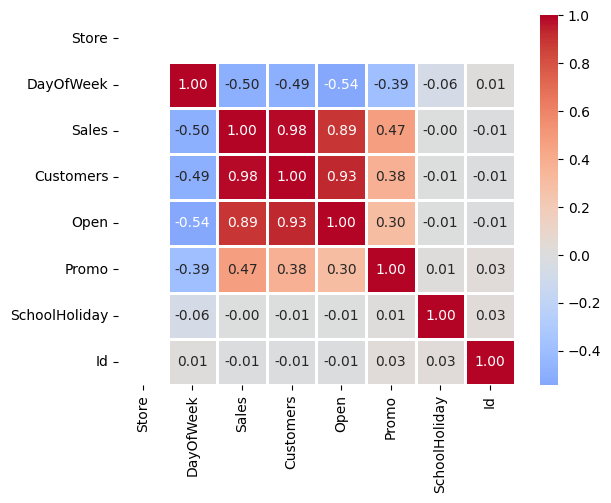

In [132]:
#Correlacion de la data 
import seaborn as sns
data_store_1_num=data_store_1[data_store_1.select_dtypes("number").columns]
data_store_1_corr=data_store_1_num.corr()

sns.heatmap(data_store_1_corr, 
            annot=True,
            fmt=".2f",
            cbar=True,
            cmap="coolwarm",
            center=0,
            linewidths=1
            )
plt.show()

In [133]:
data_store_1.drop("Customers", axis=1, inplace=True)
data_store_1

,Store,DayOfWeek,Date,Sales,Open,Promo,StateHoliday,SchoolHoliday,Id
1000485,1,2,2013-01-01,0,0,0,a,1,690197
999370,1,3,2013-01-02,5530,1,0,0,1,988300
998255,1,4,2013-01-03,4327,1,0,0,1,919910
997140,1,5,2013-01-04,4486,1,0,0,1,662609
996025,1,6,2013-01-05,4997,1,0,0,1,1008092
...,...,...,...,...,...,...,...,...,...
4460,1,1,2015-07-13,5054,1,1,0,0,308477
3345,1,2,2015-07-14,5042,1,1,0,0,704685
2230,1,3,2015-07-15,4767,1,1,0,0,64663
1115,1,4,2015-07-16,4427,1,1,0,0,324709


In [134]:
data_store_1["StateHoliday"].unique()

array(['a', '0', 0, 'b', 'c'], dtype=object)

In [135]:
data_store_1.loc[data_store_1["StateHoliday"]==0, "StateHoliday"]="0"

In [136]:
data_store_1["StateHoliday"].unique()

array(['a', '0', 'b', 'c'], dtype=object)

In [137]:
data_store_1["SchoolHoliday"].unique()

array([1, 0])

In [138]:
data_store_1["festivo"]=1*((data_store_1["StateHoliday"]!="0") | (data_store_1["SchoolHoliday"]==1))
data_store_1

,Store,DayOfWeek,Date,Sales,Open,Promo,StateHoliday,SchoolHoliday,Id,festivo
1000485,1,2,2013-01-01,0,0,0,a,1,690197,1
999370,1,3,2013-01-02,5530,1,0,0,1,988300,1
998255,1,4,2013-01-03,4327,1,0,0,1,919910,1
997140,1,5,2013-01-04,4486,1,0,0,1,662609,1
996025,1,6,2013-01-05,4997,1,0,0,1,1008092,1
...,...,...,...,...,...,...,...,...,...,...
4460,1,1,2015-07-13,5054,1,1,0,0,308477,0
3345,1,2,2015-07-14,5042,1,1,0,0,704685,0
2230,1,3,2015-07-15,4767,1,1,0,0,64663,0
1115,1,4,2015-07-16,4427,1,1,0,0,324709,0


In [139]:
data_store_1["mes"]=[x.month for x in data_store_1["Date"]]
data_store_1

,Store,DayOfWeek,Date,Sales,Open,Promo,StateHoliday,SchoolHoliday,Id,festivo,mes
1000485,1,2,2013-01-01,0,0,0,a,1,690197,1,1
999370,1,3,2013-01-02,5530,1,0,0,1,988300,1,1
998255,1,4,2013-01-03,4327,1,0,0,1,919910,1,1
997140,1,5,2013-01-04,4486,1,0,0,1,662609,1,1
996025,1,6,2013-01-05,4997,1,0,0,1,1008092,1,1
...,...,...,...,...,...,...,...,...,...,...,...
4460,1,1,2015-07-13,5054,1,1,0,0,308477,0,7
3345,1,2,2015-07-14,5042,1,1,0,0,704685,0,7
2230,1,3,2015-07-15,4767,1,1,0,0,64663,0,7
1115,1,4,2015-07-16,4427,1,1,0,0,324709,0,7


In [140]:
fechas = data_store_1["Date"].values
target = data_store_1["Sales"].values
mes    = data_store_1["mes"].values
festivo = data_store_1["festivo"].values
day_of_week = data_store_1["DayOfWeek"].values

promo = data_store_1["Promo"].values
open_ = data_store_1["Open"].values

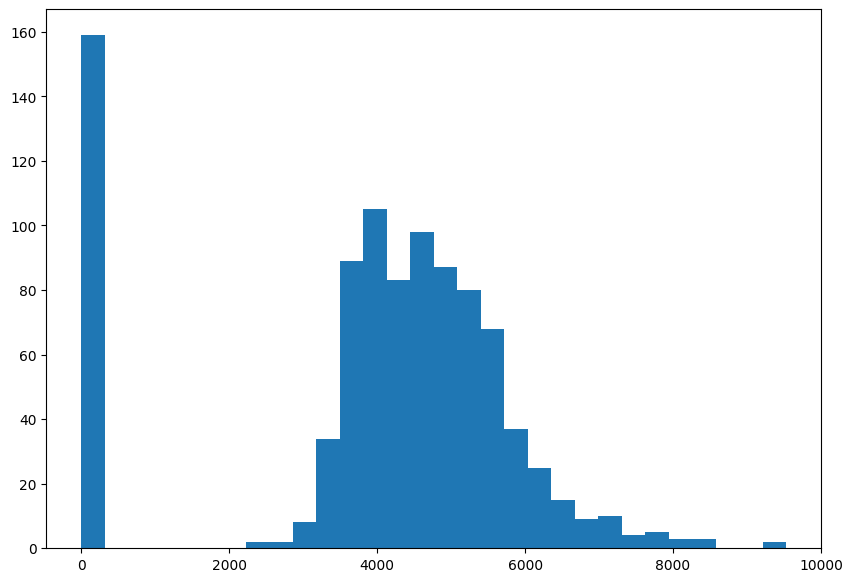

In [141]:
plt.figure(figsize=(10,7))
plt.hist(target, bins=30)
plt.show()

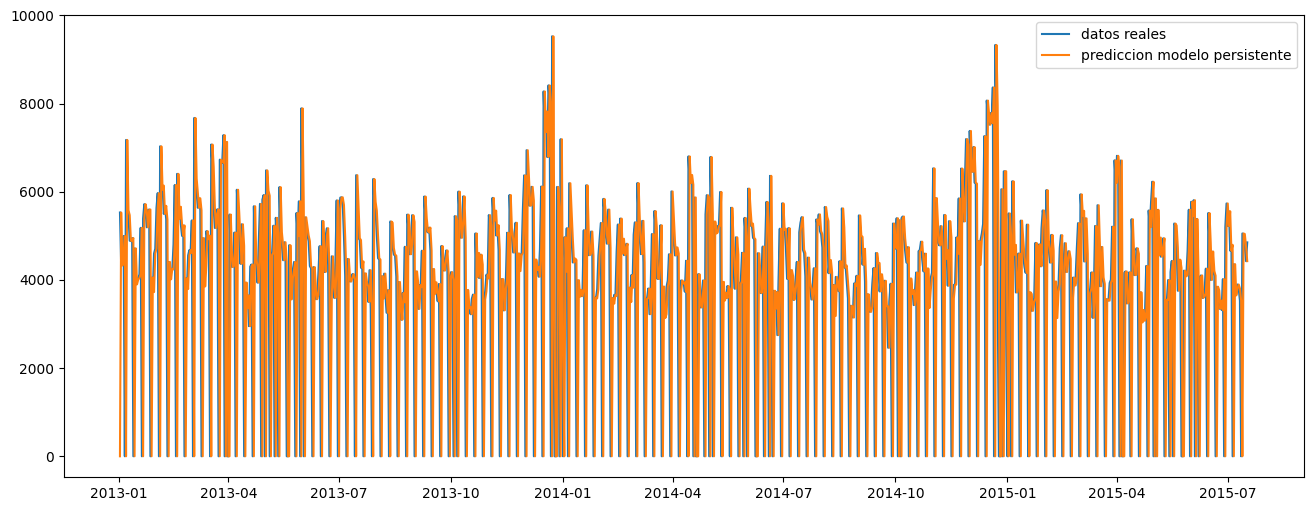

In [142]:
fechas_comparacion=fechas[1:]
target_comparacion=target[1:]
modelo_pesistente=target[0:-1]

plt.figure(figsize=(16,6))
plt.plot(fechas_comparacion, target_comparacion, label="datos reales")
plt.plot(fechas_comparacion, modelo_pesistente, label="prediccion modelo persistente")
plt.legend(loc="upper right")
plt.show()




In [143]:
#Ahora hacemos el calculo de R2 score 
r2_scores=[]
for desplazamiento in range (1,29):
    fechas_comparacion=fechas[desplazamiento:]
    target_comparacion=target[desplazamiento:]
    modelo_persistente=target[0:-desplazamiento]
    R2score=R2_score(target_comparacion, modelo_persistente)
    r2_scores.append(R2score)
    print(f"Coef de determinacion R2 para deltaT {desplazamiento}: {R2score:.2f}")


Coef de determinacion R2 para deltaT 1: -1.26
Coef de determinacion R2 para deltaT 2: -1.08
Coef de determinacion R2 para deltaT 3: -0.87
Coef de determinacion R2 para deltaT 4: -1.01
Coef de determinacion R2 para deltaT 5: -1.22
Coef de determinacion R2 para deltaT 6: -1.46
Coef de determinacion R2 para deltaT 7: 0.26
Coef de determinacion R2 para deltaT 8: -1.49
Coef de determinacion R2 para deltaT 9: -1.31
Coef de determinacion R2 para deltaT 10: -1.00
Coef de determinacion R2 para deltaT 11: -0.99
Coef de determinacion R2 para deltaT 12: -1.17
Coef de determinacion R2 para deltaT 13: -1.30
Coef de determinacion R2 para deltaT 14: 0.44
Coef de determinacion R2 para deltaT 15: -1.32
Coef de determinacion R2 para deltaT 16: -1.12
Coef de determinacion R2 para deltaT 17: -0.95
Coef de determinacion R2 para deltaT 18: -0.98
Coef de determinacion R2 para deltaT 19: -1.19
Coef de determinacion R2 para deltaT 20: -1.45
Coef de determinacion R2 para deltaT 21: 0.30
Coef de determinacion R2 

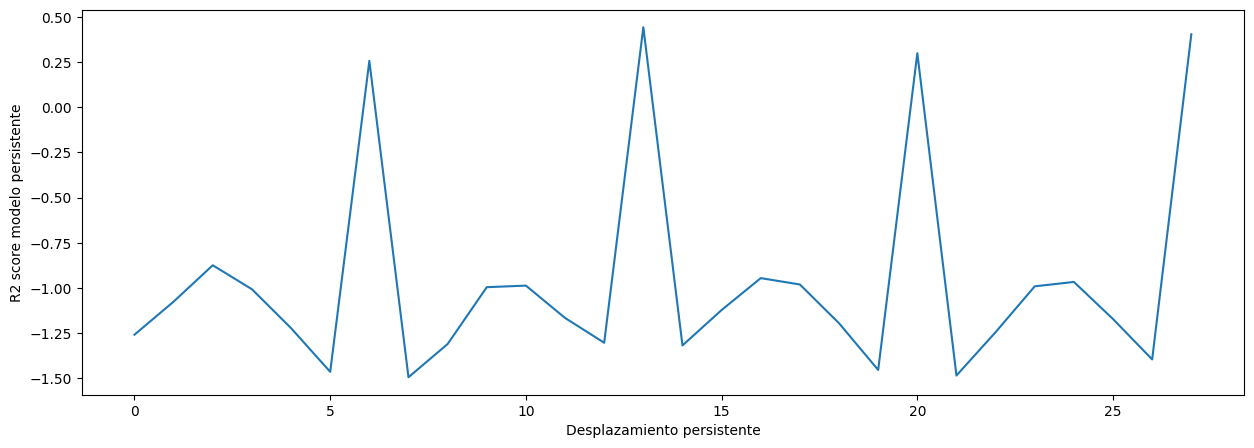

In [144]:
plt.figure(figsize=(15,5))
plt.plot(r2_scores)
plt.xlabel("Desplazamiento persistente")
plt.ylabel("R2 score modelo persistente");

### Conclusión:

- Hay una estacionalidad muy clara (ciclos) cada 7/14 días
- Mi modelo predictivo debería batir claramente el R2 score de 0.44 (modelo persistente de 14 días)

## Primer modelo: utilizamos solo la variable endógena como punto de partida

In [145]:


# Transformación de escala (ajustar el factor en función del problema)
def transform(x):
    return x/5000

def inverse_transform(x_escalado):
    return x_escalado*5000

from matplotlib.ticker import MaxNLocator

def grafica_entrenamiento(tr_mse, val_mse):
    ax=plt.figure(figsize=(10,4)).gca()
    plt.plot(1+np.arange(len(tr_mse)), tr_mse) #np.arange(3) → [0, 1, 2]
    plt.plot(1+np.arange(len(val_mse)), val_mse) #np.arange(3) → [0, 1, 2]
    plt.title('mse del modelo', fontsize=18)
    plt.xlabel('epoca', fontsize=18)
    plt.ylabel('mse', fontsize=18)
    plt.legend(['entrenamiento', 'validación'], loc='upper left')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.show()

In [146]:
target_transf=transform(target)
target_transf

array([0.    , 1.106 , 0.8654, 0.8972, 0.9994, 0.    , 1.4352, 1.116 ,
       1.0942, 0.9784, 0.9762, 0.9904, 0.    , 0.9434, 0.78  , 0.8016,
       0.8088, 0.8254, 1.0364, 0.    , 1.0788, 1.144 , 1.1156, 1.039 ,
       1.1172, 1.1196, 0.    , 0.811 , 0.745 , 0.9202, 0.9418, 1.1266,
       1.194 , 0.    , 1.4064, 1.2098, 1.228 , 1.0998, 1.1362, 1.074 ,
       0.    , 0.8818, 0.803 , 0.8504, 0.8482, 0.9618, 1.2308, 0.    ,
       1.2814, 1.0772, 1.132 , 1.0522, 1.    , 1.0474, 0.    , 0.8076,
       0.7588, 0.9116, 0.9352, 0.9222, 1.07  , 0.    , 1.535 , 1.26  ,
       1.1946, 1.1274, 1.1706, 1.1156, 0.    , 0.9898, 0.7706, 0.8682,
       1.0216, 0.985 , 1.0006, 0.    , 1.4144, 1.3126, 1.1196, 1.0358,
       1.1012, 1.1206, 0.    , 1.3458, 1.3372, 1.332 , 1.457 , 0.    ,
       1.4264, 0.    , 0.    , 1.0968, 0.925 , 0.8586, 0.878 , 1.015 ,
       0.    , 1.2092, 1.1028, 0.9806, 0.8732, 1.0526, 0.9546, 0.    ,
       0.7882, 0.6714, 0.7298, 0.5904, 0.8606, 0.87  , 0.    , 1.1344,
      

In [147]:
series=[target_transf]
nombres_series=["target_transf"]
se_saben_antes=[False]

In [148]:
from my_utils_series_temporales import enventanar, info_enventanado
W=7

X, y =enventanar(series, target=0, se_saben_antes=se_saben_antes, W_in=W)


In [149]:
target.shape

(928,)

In [150]:
print(f"X shape {X.shape}")

X shape (928, 7, 1)


In [151]:
print(f"y shape {y.shape}")

y shape (928,)


In [152]:
X[:10]

array([[[   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan]],

       [[   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan],
        [0.    ]],

       [[   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan],
        [0.    ],
        [1.106 ]],

       [[   nan],
        [   nan],
        [   nan],
        [   nan],
        [0.    ],
        [1.106 ],
        [0.8654]],

       [[   nan],
        [   nan],
        [   nan],
        [0.    ],
        [1.106 ],
        [0.8654],
        [0.8972]],

       [[   nan],
        [   nan],
        [0.    ],
        [1.106 ],
        [0.8654],
        [0.8972],
        [0.9994]],

       [[   nan],
        [0.    ],
        [1.106 ],
        [0.8654],
        [0.8972],
        [0.9994],
        [0.    ]],

       [[0.    ],
        [1.106 ],
        [0.8654],
        [0.8972],
        [0.9994],
        [0.   

In [153]:
y[:10]

array([0.    , 1.106 , 0.8654, 0.8972, 0.9994, 0.    , 1.4352, 1.116 ,
       1.0942, 0.9784])

In [154]:
punto_corte=int(len(target)*0.8)
print(punto_corte)

742


In [155]:
Nval=200

In [156]:

X_aux=X[W:punto_corte]
y_aux=y[W:punto_corte]
fechas_aux=fechas[W:punto_corte]
target_aux=target[W:punto_corte]

X_val=X_aux[-Nval:]
y_val=y_aux[-Nval:]
fechas_val=fechas_aux[-Nval:]
target_val=target_aux[-Nval:]

X_train=X_aux[:-Nval]
y_train=y_aux[:-Nval]
fechas_train=fechas_aux[:-Nval]
target_train=target_aux[:-Nval]

X_test=X[punto_corte:]
y_test=y[punto_corte:]
fechas_test=fechas[punto_corte:]
target_test=target[punto_corte:]

In [157]:
print(f"{X_train.shape}, {y_train.shape} ")

(535, 7, 1), (535,) 


In [158]:
print(f"{X_val.shape}, {y_val.shape} ")

(200, 7, 1), (200,) 


In [159]:
print(f"{X_test.shape}, {y_test.shape} ")

(186, 7, 1), (186,) 


In [160]:
from keras.layers import Dense, LSTM, GRU
from keras.optimizers import RMSprop
from keras.models import Sequential
from keras.callbacks import ModelCheckpoint

model=Sequential()
model.add(LSTM(5, input_shape=(X_train.shape[1:])))
model.add(Dense(1, activation="relu"))

optimizer_gru=RMSprop(1/1000)

model.compile(optimizer=optimizer_gru, loss="mean_squared_error")
model.summary()

c:\Users\CHOPPE\Documents\CEROSA 2024\anaconda\envs\env-PC4-mbit\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 5)              │           140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 146 (584.00 B)

 Trainable params: 146 (584.00 B)

 Non-trainable params: 0 (0.00 B)

In [161]:
from os import getcwd
current_wd=getcwd().replace("\\", "/")
Primer_modelo_store1=current_wd+"/store_1/Primer_modelo_var_endo.keras"
print(Primer_modelo_store1)


c:/Users/CHOPPE/Desktop/Software Development/Series_temporales_redes_recurrentes_rossmann/store_1/Primer_modelo_var_endo.keras


In [162]:
from keras.callbacks import ModelCheckpoint

checkpoint=ModelCheckpoint(Primer_modelo_store1, monitor="val_loss", verbose=2, save_best_only=True)

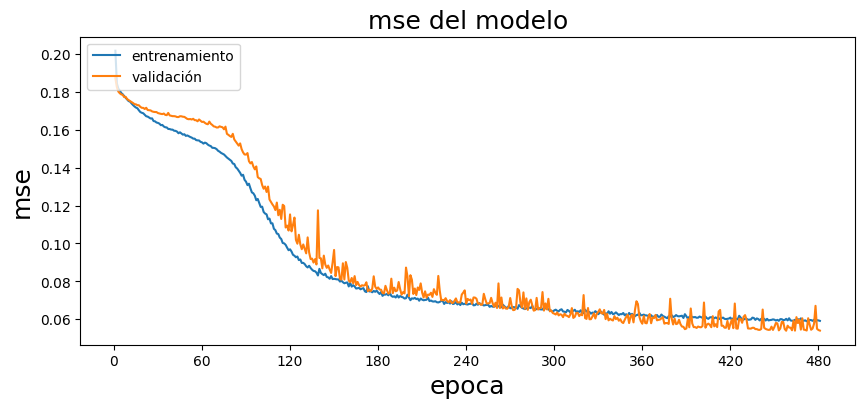


Epoch 1: val_loss did not improve from 0.05400

Epoch 1: val_loss improved from 0.05400 to 0.05396, saving model to c:/Users/CHOPPE/Desktop/Software Development/Series_temporales_redes_recurrentes_rossmann/store_1/Primer_modelo_var_endo.keras

Epoch 1: finished saving model to c:/Users/CHOPPE/Desktop/Software Development/Series_temporales_redes_recurrentes_rossmann/store_1/Primer_modelo_var_endo.keras

Epoch 1: val_loss did not improve from 0.05396

Epoch 1: val_loss did not improve from 0.05396

Epoch 1: val_loss did not improve from 0.05396

Epoch 1: val_loss did not improve from 0.05396

Epoch 1: val_loss did not improve from 0.05396

Epoch 1: val_loss did not improve from 0.05396

Epoch 1: val_loss did not improve from 0.05396

Epoch 1: val_loss did not improve from 0.05396

Epoch 1: val_loss did not improve from 0.05396

Epoch 1: val_loss did not improve from 0.05396

Epoch 1: val_loss did not improve from 0.05396

Epoch 1: val_loss did not improve from 0.05396

Epoch 1: val_loss

In [163]:
from IPython.display import clear_output
epocas=500
losses_train=[]
losses_val=[]

for i in range (epocas):
    history=model.fit(X_train, y_train, epochs=1, verbose=0, batch_size=64, validation_data=(X_val, y_val), callbacks=checkpoint)
    losses_train.append(history.history["loss"])
    losses_val.append(history.history["val_loss"])

    if (i%40)==0:
        clear_output()
        grafica_entrenamiento(losses_train, losses_val)




In [164]:
from keras.models import load_model
model=load_model(Primer_modelo_store1)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


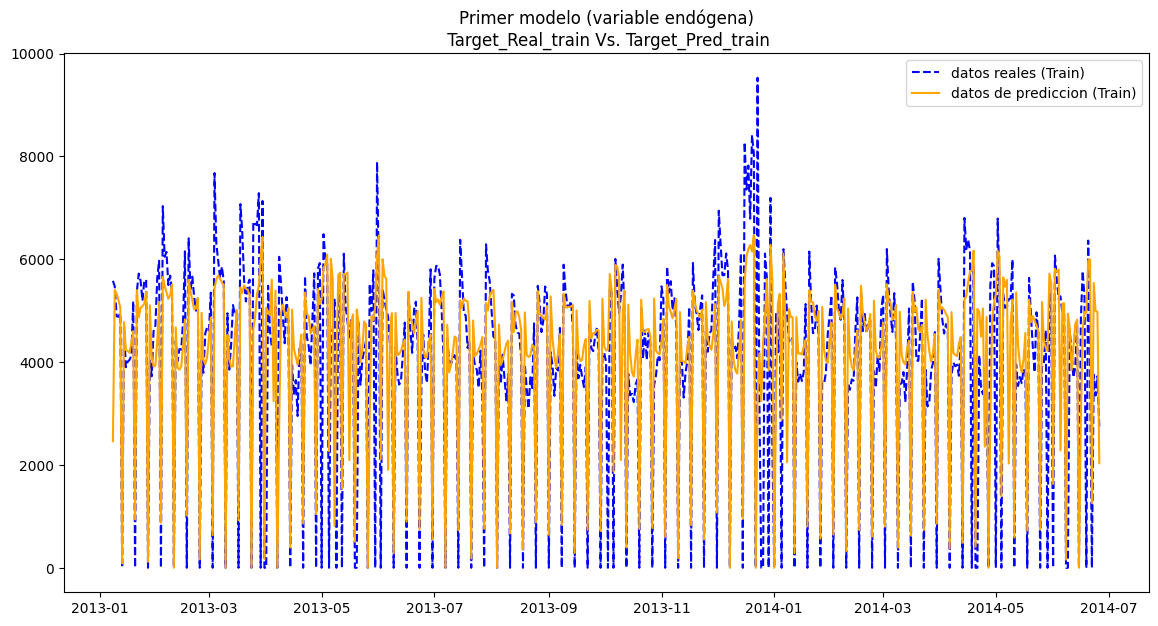

In [165]:
#Evaluacion en Train

#Predicción en Train
y_train_predicted_transf=model.predict(X_train)
target_predicted_train=inverse_transform(y_train_predicted_transf)

#Plot en Train
plt.figure(figsize=(14,7))
plt.plot(fechas_train, target_train, linestyle="--", label="datos reales (Train)", color="blue")
plt.plot(fechas_train, target_predicted_train, label="datos de prediccion (Train)", color="orange")
plt.title("Primer modelo (variable endógena)\n Target_Real_train Vs. Target_Pred_train")
plt.legend(loc="upper right")

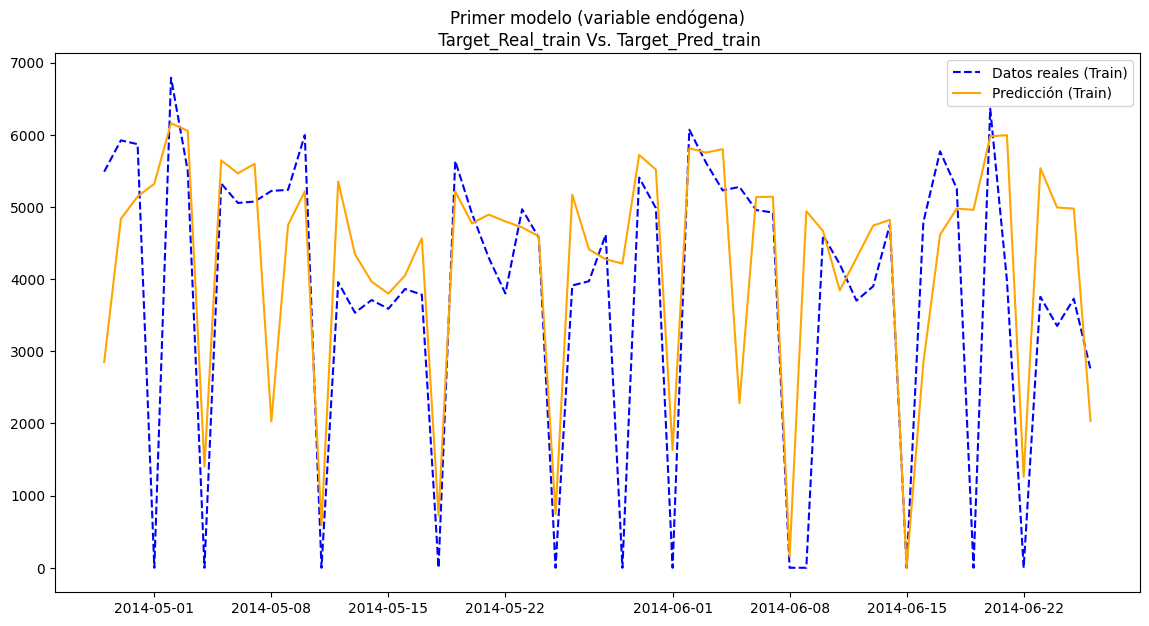

In [166]:
# Hacemos Zoom en la imagen, analizamos puntualmente ultimos 2 meses
plt.figure(figsize=(14,7))
plt.plot(fechas_train[-60:], target_train[-60:], linestyle="--", label="Datos reales (Train)", color="blue")
plt.plot(fechas_train[-60:], target_predicted_train[-60:], label="Predicción (Train)", color="orange")
plt.title("Primer modelo (variable endógena)\n Target_Real_train Vs. Target_Pred_train")
plt.legend(loc="upper right")

In [171]:
#Metricas de evaluacion para train:
from sklearn.metrics import r2_score as R2
R2_train=R2(target_train, target_predicted_train)
print(f"Coeficiente de determinación R2 para Train: {R2_train:.2f}")

Coeficiente de determinación R2 para Train: 0.64


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


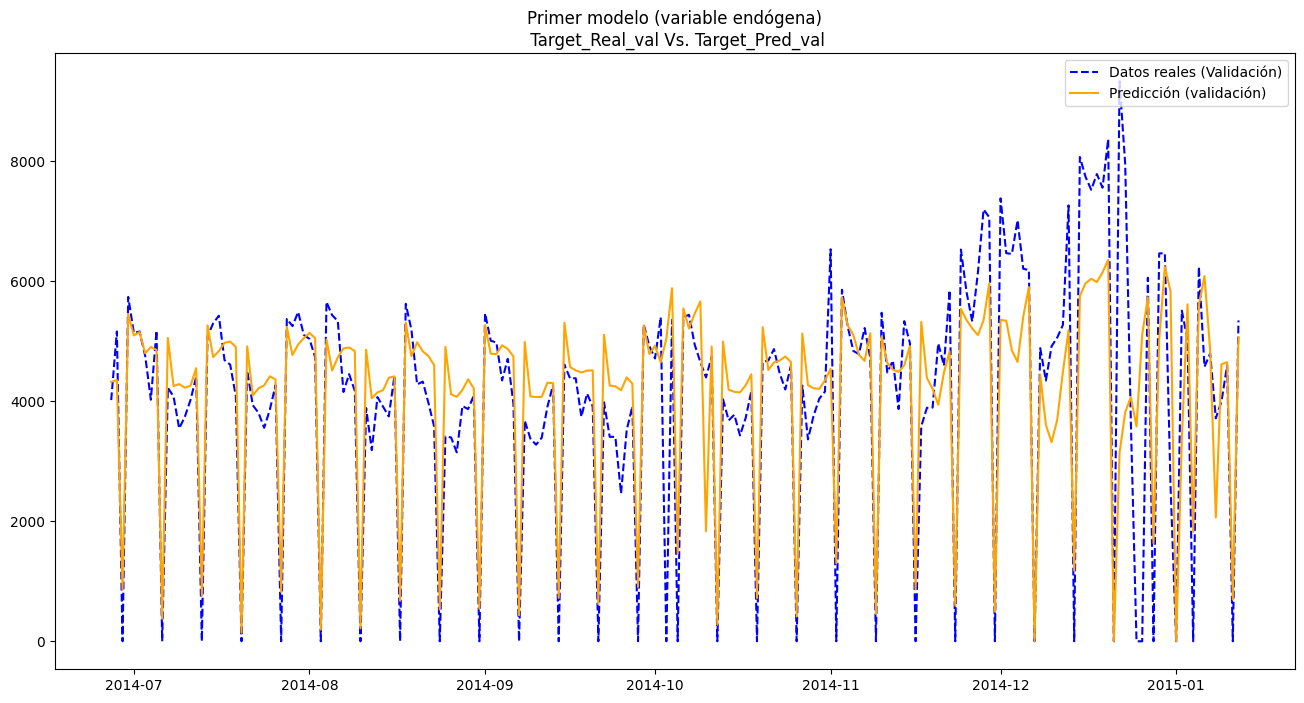

In [172]:
#Evaluacion en Validación

#Prediccion en validación
y_val_predicted_tranf=model.predict(X_val)
target_predicted_val=inverse_transform(y_val_predicted_tranf)

#Plot en validación
plt.figure(figsize=(16,8))
plt.plot(fechas_val, target_val, linestyle="--", label="Datos reales (Validación)", color="blue")
plt.plot(fechas_val, target_predicted_val, label="Predicción (validación)", color="orange")
plt.legend(loc="upper right")
plt.title("Primer modelo (variable endógena)\n Target_Real_val Vs. Target_Pred_val")
plt.show()

In [173]:
#Metricas de evaluacion para validacion:
from sklearn.metrics import r2_score as R2
R2_val=R2(target_val, target_predicted_val)
print(f"Coeficiente de determinación R2 en validacion: {R2_val:.2f}")

Coeficiente de determinación R2 en validacion: 0.69


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


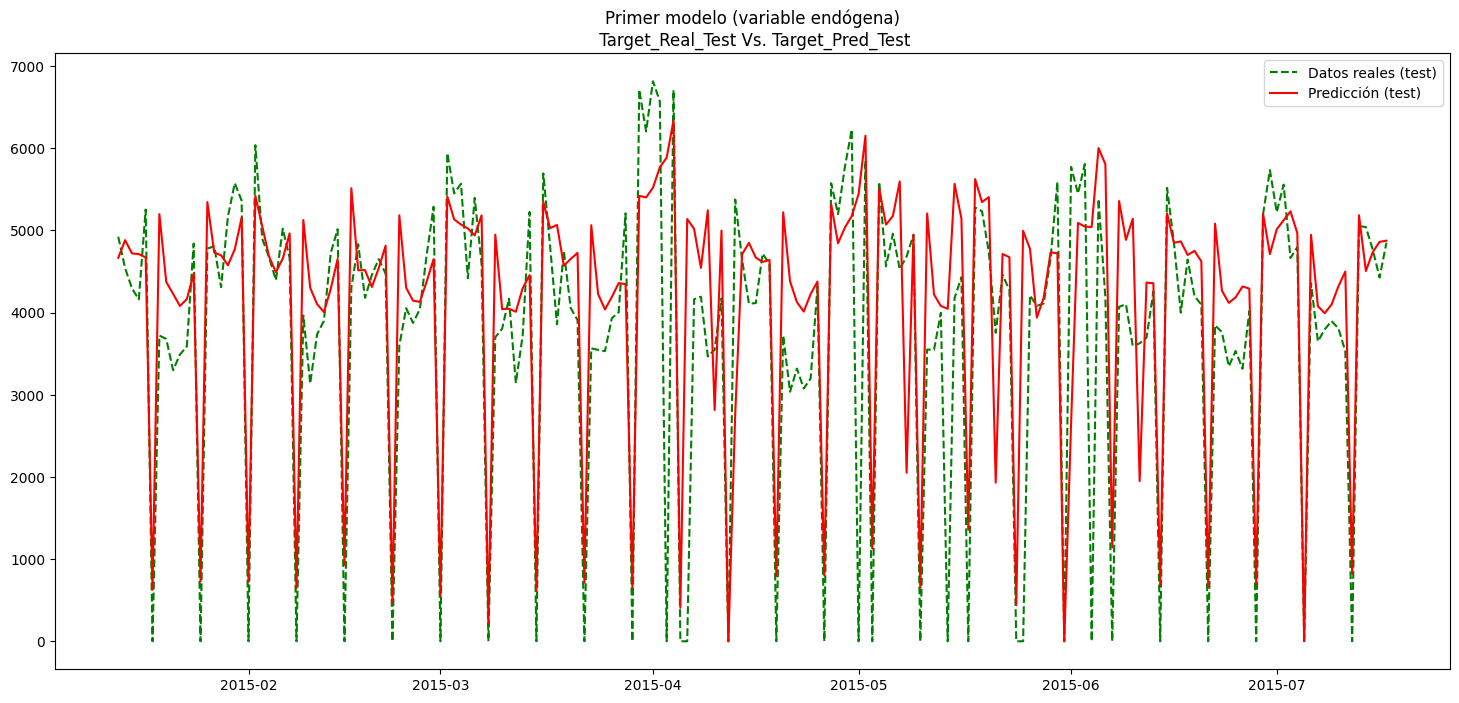

In [174]:
#Evaluacion en Test

#Prediccion en Test
y_test_predicted_tranf=model.predict(X_test)
target_predicted_test=inverse_transform(y_test_predicted_tranf)

#Plot en Test
plt.figure(figsize=(18,8))
plt.plot(fechas_test, target_test, label="Datos reales (test)", linestyle="--", color="green")
plt.plot(fechas_test, target_predicted_test, label="Predicción (test)", color="red")
plt.legend(loc="upper right")
plt.title("Primer modelo (variable endógena)\n Target_Real_Test Vs. Target_Pred_Test")
plt.show()


In [175]:
#Metricas de evaluacion en Test:
from sklearn.metrics import r2_score as R2 
R2_test=R2(target_test, target_predicted_test)
print(f"Coeficiente de determinación R2 en Test: {R2_test:.2f}")

Coeficiente de determinación R2 en Test: 0.57


In [ ]:
#Conclusión: Nuestro primer modelo unicamente con la variable endógena ha sido capaz de superar al modelo persistente.
#Hemos obtenido un Coeficiente de determinación de 0.57 superior al 0.44 del modelo persistente. En el siguiente paso trataremos de mejorar el modelo 
#integrando variables exogenas con el fin de obtener mejores resultados de predicción.

## Segundo modelo: utilizamos la variable endógena y exógenas

In [176]:
data_store_1[:10]

,Store,DayOfWeek,Date,Sales,Open,Promo,StateHoliday,SchoolHoliday,Id,festivo,mes
1000485,1,2,2013-01-01,0,0,0,a,1,690197,1,1
999370,1,3,2013-01-02,5530,1,0,0,1,988300,1,1
998255,1,4,2013-01-03,4327,1,0,0,1,919910,1,1
997140,1,5,2013-01-04,4486,1,0,0,1,662609,1,1
996025,1,6,2013-01-05,4997,1,0,0,1,1008092,1,1
994910,1,7,2013-01-06,0,0,0,0,1,73679,1,1
993795,1,1,2013-01-07,7176,1,1,0,1,935813,1,1
992680,1,2,2013-01-08,5580,1,1,0,1,122545,1,1
991565,1,3,2013-01-09,5471,1,1,0,1,524702,1,1
990450,1,4,2013-01-10,4892,1,1,0,1,936951,1,1


In [177]:
from my_utils_series_temporales import int2dummy

mes_dummy=int2dummy(mes, minimo=1, maximo=12)
mes_dummy[:10]


array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [178]:
mes_dummy[:,0].shape

(928,)

In [179]:
day_dummy=int2dummy(day_of_week, minimo=1, maximo=7)
day_dummy[:10]

array([[0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0.]])

In [180]:
series=[target_transf, festivo, open_, promo]
nombres_series=["target_transf", "festivo", "open", "promo"]
se_saben_antes=[False, True, True, True]

for m in range (0,12):
    series.append(mes_dummy[:, m])
    se_saben_antes.append(True)

for day in range (0, 7):
    series.append(day_dummy[:,day])
    se_saben_antes.append(True)

In [181]:
from my_utils_series_temporales import enventanar, info_enventanado
W=7

X, y= enventanar(series=series, target=0, se_saben_antes=se_saben_antes, W_in=W)
X.shape, y.shape

((928, 7, 23), (928,))

In [182]:
X_aux=X[W:punto_corte]
y_aux=y[W:punto_corte]
fechas_aux=fechas[W:punto_corte]
target_aux=target[W:punto_corte]

X_val=X_aux[-Nval:]
y_val=y_aux[-Nval:]
fechas_val=fechas_aux[-Nval:]
target_val=target_aux[-Nval:]

X_train=X_aux[:-Nval]
y_train=y_aux[:-Nval]
fechas_train=fechas_aux[:-Nval]
target_train=target_aux[:-Nval]

X_test=X[punto_corte:]
y_test=y[punto_corte:]
fechas_test=fechas[punto_corte:]
target_test=target[punto_corte:]

In [189]:
from keras.layers import Dense, GRU, LSTM
from keras.optimizers import RMSprop
from keras.models import Sequential

model=Sequential()
model.add(GRU(5, input_shape=X_train.shape[1:]))
model.add(Dense(1, activation="relu"))

optimizer_gru_endo=RMSprop(1/1000)

model.compile(optimizer=optimizer_gru_endo, loss="mean_squared_error")
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_4 (GRU)                     │ (None, 5)              │           450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 456 (1.78 KB)

 Trainable params: 456 (1.78 KB)

 Non-trainable params: 0 (0.00 B)

In [190]:
from os import getcwd

ruta_actual=getcwd().replace("\\", "/")
segundo_modelo_path=ruta_actual+"/store_1/segundo_modelo_var_exo.keras"

In [191]:
from keras.callbacks import ModelCheckpoint

checkpoint=ModelCheckpoint(segundo_modelo_path, verbose=2, save_best_only=True, monitor="val_loss")

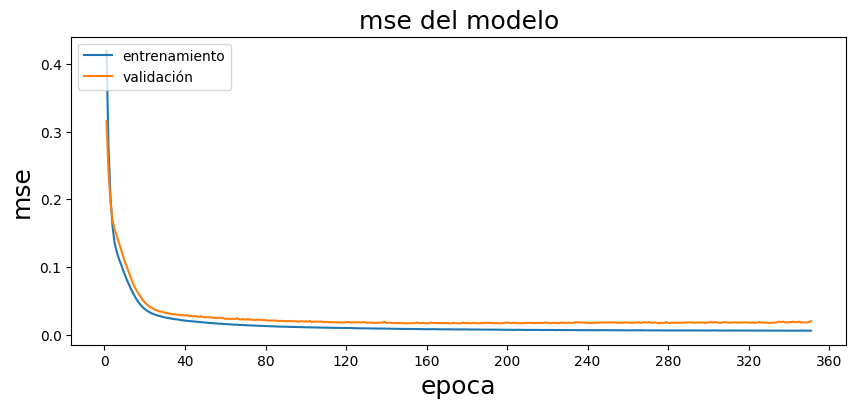


Epoch 1: val_loss did not improve from 0.01652

Epoch 1: val_loss did not improve from 0.01652

Epoch 1: val_loss did not improve from 0.01652

Epoch 1: val_loss did not improve from 0.01652

Epoch 1: val_loss did not improve from 0.01652

Epoch 1: val_loss did not improve from 0.01652

Epoch 1: val_loss did not improve from 0.01652

Epoch 1: val_loss did not improve from 0.01652

Epoch 1: val_loss did not improve from 0.01652

Epoch 1: val_loss did not improve from 0.01652

Epoch 1: val_loss did not improve from 0.01652

Epoch 1: val_loss did not improve from 0.01652

Epoch 1: val_loss did not improve from 0.01652

Epoch 1: val_loss did not improve from 0.01652

Epoch 1: val_loss did not improve from 0.01652

Epoch 1: val_loss did not improve from 0.01652

Epoch 1: val_loss did not improve from 0.01652

Epoch 1: val_loss did not improve from 0.01652

Epoch 1: val_loss did not improve from 0.01652

Epoch 1: val_loss did not improve from 0.01652

Epoch 1: val_loss did not improve from 

In [192]:
from IPython.display import clear_output

epocas=400
batchsize=64
train_losses=[]
val_losses=[]

for e in range (epocas):
    history=model.fit(X_train, y_train, verbose=0, epochs=1, batch_size=batchsize, validation_data=(X_val, y_val), callbacks=checkpoint)
    train_losses.append(history.history["loss"])
    val_losses.append(history.history["val_loss"])

    if (e%50)==0:
        clear_output()
        grafica_entrenamiento(train_losses, val_losses)


In [193]:
#Cargamos el modelo
from keras.models import load_model
model=load_model(segundo_modelo_path)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


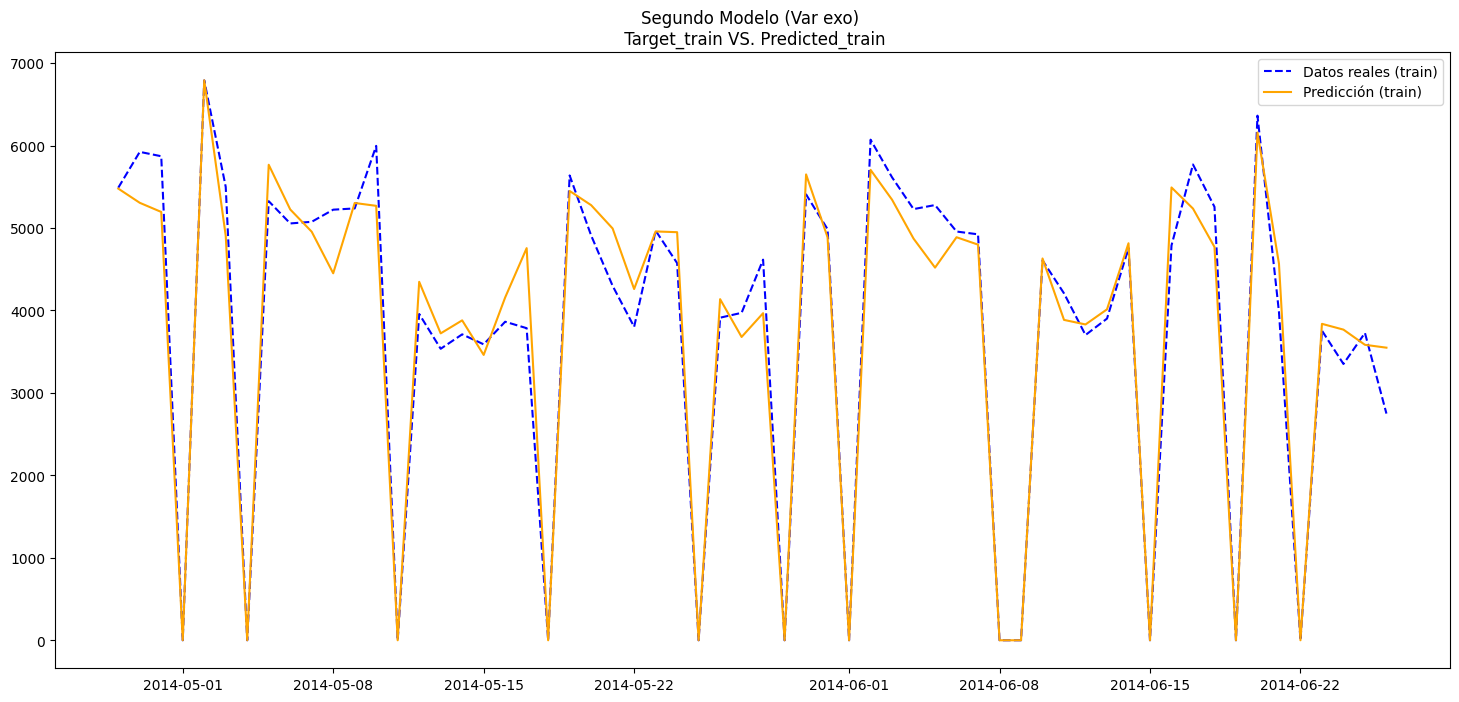

In [194]:
#Evaluamos el modelo en Train

#Prediccion en Train y transf
y_train_predicted_transf=model.predict(X_train)
target_predicted_train=inverse_transform(y_train_predicted_transf)

#Plot en Train en una sección 
plt.figure(figsize=(18,8))
plt.plot(fechas_train[-60:], target_train[-60:], label="Datos reales (train)", linestyle="--", color="blue")
plt.plot(fechas_train[-60:], target_predicted_train[-60:], label="Predicción (train)", color="orange")
plt.title("Segundo Modelo (Var exo) \n Target_train VS. Predicted_train")
plt.legend(loc="upper right")

In [195]:
#Ahora calculamos el coeficiente de determinacion para Train
from sklearn.metrics import r2_score as R2

R2_Score_train=R2(target_train, target_predicted_train)
print(f"Coeficiente de determinacion R2 para Train con variables exogenas: {R2_Score_train:.2f}")

Coeficiente de determinacion R2 para Train con variables exogenas: 0.95


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


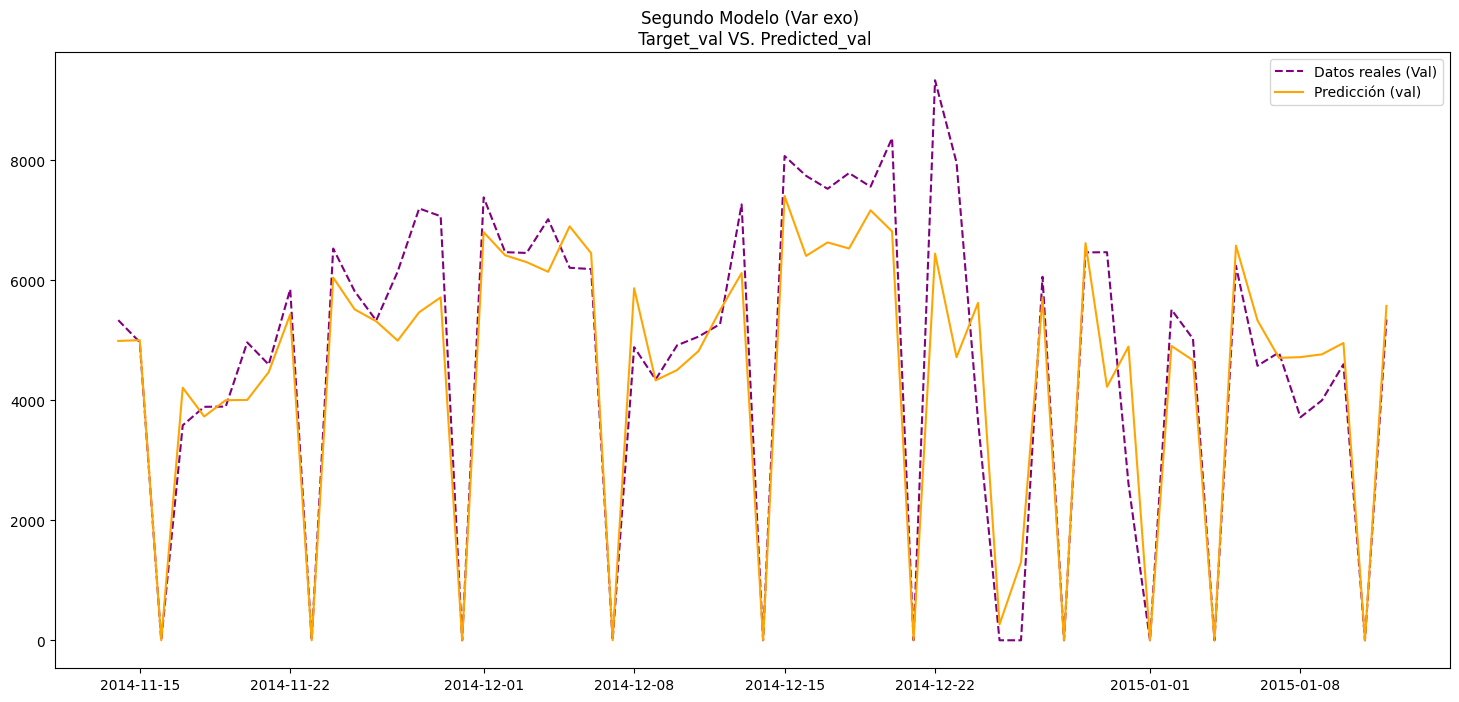

In [198]:
#Evaluamos el modelo en Validación

#Predicción en Validación
y_val_predicted_transf=model.predict(X_val)
target_predicted_val=inverse_transform(y_val_predicted_transf)

#Plot en Validación
plt.figure(figsize=(18,8))
plt.plot(fechas_val[-60:], target_val[-60:], label="Datos reales (Val)", linestyle="--", color="purple")
plt.plot(fechas_val[-60:], target_predicted_val[-60:], label="Predicción (val)", color="orange")
plt.title("Segundo Modelo (Var exo) \n Target_val VS. Predicted_val")
plt.legend(loc="upper right")

In [199]:
#Ahora calculamos el coeficiente de determinacion para validacion
from sklearn.metrics import r2_score as R2

R2_Score_val=R2(target_val, target_predicted_val)
print(f"Coeficiente de determinacion R2 en Validación con variables exogenas: {R2_Score_val:.2f}")

Coeficiente de determinacion R2 en Validación con variables exogenas: 0.91


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


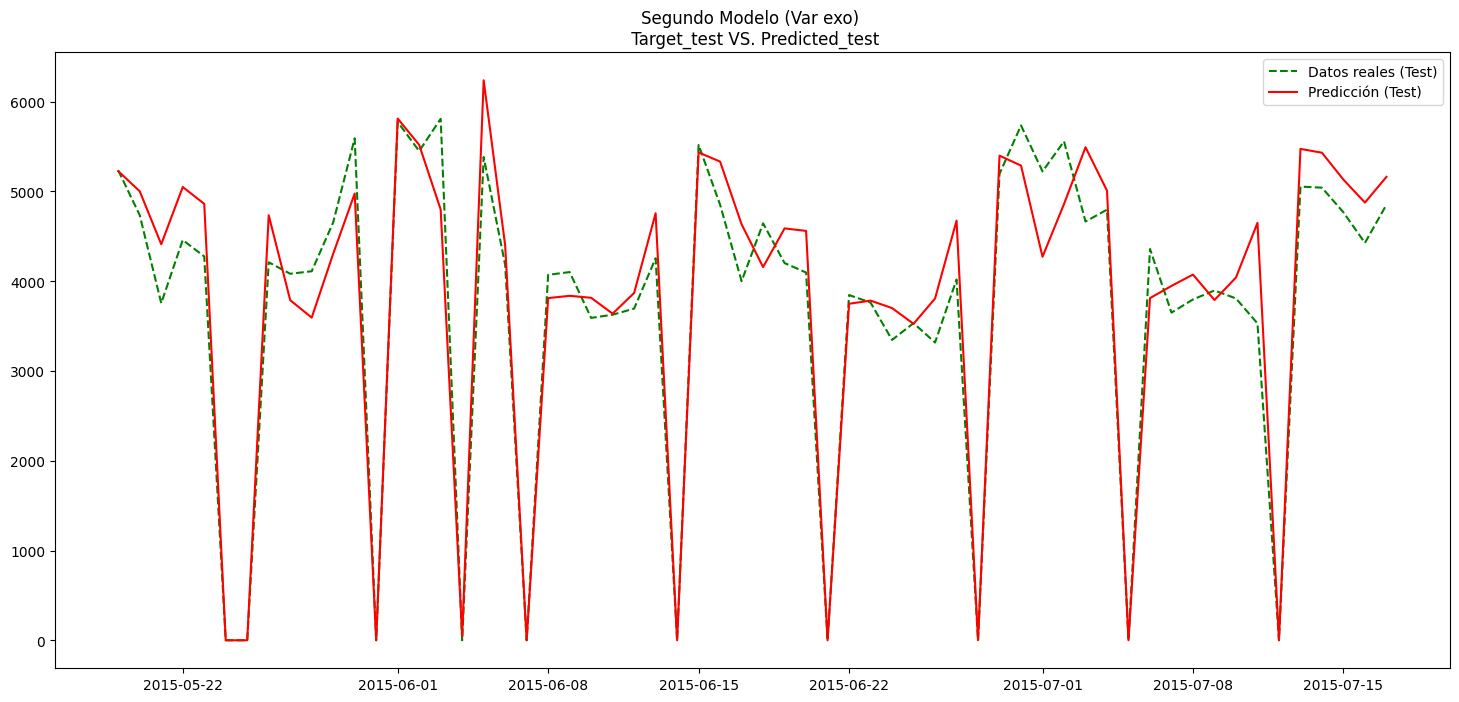

In [200]:
#Evaluamos el modelo en Test

#Predicción en Test
y_test_predicted_transf=model.predict(X_test)
target_predicted_test=inverse_transform(y_test_predicted_transf)

#Plot en Test
plt.figure(figsize=(18,8))
plt.plot(fechas_test[-60:], target_test[-60:], label="Datos reales (Test)", linestyle="--", color="green")
plt.plot(fechas_test[-60:], target_predicted_test[-60:], label="Predicción (Test)", color="red")
plt.title("Segundo Modelo (Var exo) \n Target_test VS. Predicted_test")
plt.legend(loc="upper right")

In [201]:
#Ahora calculamos el coeficiente de determinacion para validacion
from sklearn.metrics import r2_score as R2

R2_Score_test=R2(target_test, target_predicted_test)
print(f"Coeficiente de determinacion R2 en test con variables exógenas: {R2_Score_test:.2f}")

Coeficiente de determinacion R2 en test con variables exógenas: 0.93


In [ ]:
#Conclusión: integrando variables exógenas el modelo ha mejorado significativamente. Hemos alcanzado un coeficiente de determinación de 0.93 en Test Vs el 0.66 del primer 
#modelo que solo consideraba la variable endógena. Al ajustar los disintos hiperarametros de la red neuronal recurrente estos son los mejores resultados que hemos conseguido. 

**Ejercicio:**

Optimizar la red ajustando estos hiperparámetros:

- W  --> Respuesta: (W=7)
- Número de neuronas en capa recurrente --> Respuesta: (5)
- Tipo de capa recurrente (LSTM, GRU, RNN)--> Respuesta: (GRU)
- Algoritmo de optimización (y su learning rate) --> Respuesta: (RMSprop(1/1000))
- Variables del modelo--> Respuesta: [open_, promo, day_of_week, mes, festivo]

In [ ]:
#Procedemos a evaluar si el modelo puede mejorar significativamente al integrar embeddings en las variables categoricas day_of_the_week y mes

# Tercer modelo, Construcción del modelo con embeddings

In [528]:
#Proceso: 
#1)Normalizar transformar variable Target
#2)Enventanar cada variable por separado
#3)Separar ventanas en train, validacion y test
#4) Utilizar input y concatenate para crear red con variables categóricas y variables no categoricas


In [202]:
# media_target= target[:punto_corte].mean() # media en training
# std_target = target[:punto_corte].std()  # std en training

# def transform(x):
#     return (x - media_target) / std_target # "Z-score"

# def inverse_transform(xp):
#     return std_target*xp + media_target
    
# Transformación de escala (ajustar el factor en función del problema)
def transform(x):
    return x/5000

def inverse_transform(x_escalado):
    return x_escalado*5000
# Regla de oro: las estadísticas para normalizar solo se pueden calcular con datos de training

target_transf= transform(target)
target_recuperado = inverse_transform(target_transf)
print(target_transf[:5])
print(target_recuperado[:5])

[0.     1.106  0.8654 0.8972 0.9994]
[   0. 5530. 4327. 4486. 4997.]


In [203]:
data_store_1

,Store,DayOfWeek,Date,Sales,Open,Promo,StateHoliday,SchoolHoliday,Id,festivo,mes
1000485,1,2,2013-01-01,0,0,0,a,1,690197,1,1
999370,1,3,2013-01-02,5530,1,0,0,1,988300,1,1
998255,1,4,2013-01-03,4327,1,0,0,1,919910,1,1
997140,1,5,2013-01-04,4486,1,0,0,1,662609,1,1
996025,1,6,2013-01-05,4997,1,0,0,1,1008092,1,1
...,...,...,...,...,...,...,...,...,...,...,...
4460,1,1,2015-07-13,5054,1,1,0,0,308477,0,7
3345,1,2,2015-07-14,5042,1,1,0,0,704685,0,7
2230,1,3,2015-07-15,4767,1,1,0,0,64663,0,7
1115,1,4,2015-07-16,4427,1,1,0,0,324709,0,7


In [204]:
mes.min(), mes.max(), day_of_week.min(), day_of_week.max()

(np.int64(1), np.int64(12), np.int64(1), np.int64(7))

In [205]:
mes=mes-1 # mes (empezando desde 0, ya que las categorías en capa embedding empiezan en 0)
day_of_week=day_of_week-1 #day_of_week (empezando desde 0)

In [206]:
# Procedemos a enventanar cada variable previo al train_test_split data
from my_utils_series_temporales import enventanar, info_enventanado
W=7
#Enventanar Target
series0=[target_transf]
se_saben_antes0=[False]
X_0, y=enventanar(series=series0, target=0, se_saben_antes=se_saben_antes0, W_in=W)

#Enventanar Open
series1=[open_]
se_saben_antes1=[True]
X_1, _=enventanar(series=series1, target=0, se_saben_antes=se_saben_antes1, W_in=W)

#Enventanar festivo
series2=[festivo]
se_saben_antes2=[True]
X_2, _=enventanar(series=series2, target=0, se_saben_antes=se_saben_antes2, W_in=W)

#Enventanar Promo
series3=[promo]
se_saben_antes3=[True]
X_3, _=enventanar(series=series3, target=0, se_saben_antes=se_saben_antes3, W_in=W)

#Enventanar day
series4=[day_of_week]
se_saben_antes4=[True]
X_4, _=enventanar(series=series4, target=0, se_saben_antes=se_saben_antes4, W_in=W)

#Enventanar mes
series5=[mes]
se_saben_antes5=[True]
X_5, _=enventanar(series=series5, target=0, se_saben_antes=se_saben_antes5, W_in=W)

In [207]:
#Aux
X_0_aux=X_0[W:punto_corte]
y_aux=y[W:punto_corte]

X_1_aux=X_1[W:punto_corte]
X_2_aux=X_2[W:punto_corte]
X_3_aux=X_3[W:punto_corte]
X_4_aux=X_4[W:punto_corte]
X_5_aux=X_5[W:punto_corte]

fechas_aux=fechas[W:punto_corte]
target_aux=target[W:punto_corte]

#Validacion variables
X_0_val=X_0_aux[-Nval:]
y_val=y_aux[-Nval:]

X_1_val=X_1_aux[-Nval:]
X_2_val=X_2_aux[-Nval:]
X_3_val=X_3_aux[-Nval:]
X_4_val=X_4_aux[-Nval:]
X_5_val=X_5_aux[-Nval:]

#Validacion fechas y target
fechas_val=fechas_aux[-Nval:]
target_val=target_aux[-Nval:]


#Training variables
X_0_train=X_0_aux[:-Nval]
y_train=y_aux[:-Nval]

X_1_train=X_1_aux[:-Nval]
X_2_train=X_2_aux[:-Nval]
X_3_train=X_3_aux[:-Nval]
X_4_train=X_4_aux[:-Nval]
X_5_train=X_5_aux[:-Nval]

#Training fechas y target
fechas_train=fechas_aux[:-Nval]
target_train=target_aux[:-Nval]

#Test variables
X_0_test=X_0[punto_corte:]
y_test=y[punto_corte:]

X_1_test=X_1[punto_corte:]
X_2_test=X_2[punto_corte:]
X_3_test=X_3[punto_corte:]
X_4_test=X_4[punto_corte:]
X_5_test=X_5[punto_corte:]

#Test fechas y target
fechas_test=fechas[punto_corte:]
target_test=target[punto_corte:]

In [208]:
print (X_0_train.shape, X_1_train.shape, X_2_train.shape, X_3_train.shape, X_4_train.shape, X_5_train.shape, y_train.shape)

(535, 7, 1) (535, 7, 1) (535, 7, 1) (535, 7, 1) (535, 7, 1) (535, 7, 1) (535,)


In [209]:
print (X_0_val.shape, X_1_val.shape, X_2_val.shape, X_3_val.shape, X_4_val.shape, X_5_val.shape, y_val.shape)

(200, 7, 1) (200, 7, 1) (200, 7, 1) (200, 7, 1) (200, 7, 1) (200, 7, 1) (200,)


In [210]:
print (X_0_test.shape, X_1_test.shape, X_2_test.shape, X_3_test.shape, X_4_test.shape, X_5_test.shape, y_test.shape)

(186, 7, 1) (186, 7, 1) (186, 7, 1) (186, 7, 1) (186, 7, 1) (186, 7, 1) (186,)


In [224]:
from keras.layers import Dense, GRU, LSTM, Embedding, Input, concatenate
from keras.models import Model

dim_embedding = 2

# Inputs numéricos o binarios
input0 = Input(shape=(W, 1), name="target_transf")
input1 = Input(shape=(W, 1), name="open_")
input2 = Input(shape=(W, 1), name="festivo")
input3 = Input(shape=(W, 1), name="promo")

# Inputs categóricos
input4 = Input(shape=(W,), name="day_of_week")
input5 = Input(shape=(W,), name="mes")

# Embeddings
embedding4 = Embedding(input_dim=7, output_dim=dim_embedding, name="embedding_day_of_week")(input4)
embedding5 = Embedding(input_dim=12, output_dim=dim_embedding, name="embedding_mes")(input5)

# Concatenación
aux1 = concatenate([
    input0,
    input1,
    input2,
    input3,
    embedding4,
    embedding5
])

aux2 = GRU(5)(aux1)
aux3 = Dense(1, activation="relu")(aux2)

model = Model(
    inputs=[input0, input1, input2, input3, input4, input5],
    outputs=aux3
)
optimizer_gru_endo=RMSprop(1/1000)
model.compile(loss="mean_squared_error", optimizer=optimizer_gru_endo)
model.summary()

Model: "functional_25"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ day_of_week         │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mes (InputLayer)    │ (None, 7)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ target_transf       │ (None, 7, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ open_ (InputLayer)  │ (None, 7, 1)      │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ festivo             │ (None, 7, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ promo (InputLayer)  │ (None, 7, 1)      │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_day_of_w… │ (None, 7, 2)      │         14 │ day_of_week[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_mes       │ (None, 7, 2)      │         24 │ mes[0][0]         │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 7, 8)      │          0 │ target_transf[0]… │
│ (Concatenate)       │                   │            │ open_[0][0],      │
│                     │                   │            │ festivo[0][0],    │
│                     │                   │            │ promo[0][0],      │
│                     │                   │            │ embedding_day_of… │
│                     │                   │            │ embedding_mes[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_6 (GRU)         │ (None, 5)         │        225 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 1)         │          6 │ gru_6[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 269 (1.05 KB)

 Trainable params: 269 (1.05 KB)

 Non-trainable params: 0 (0.00 B)

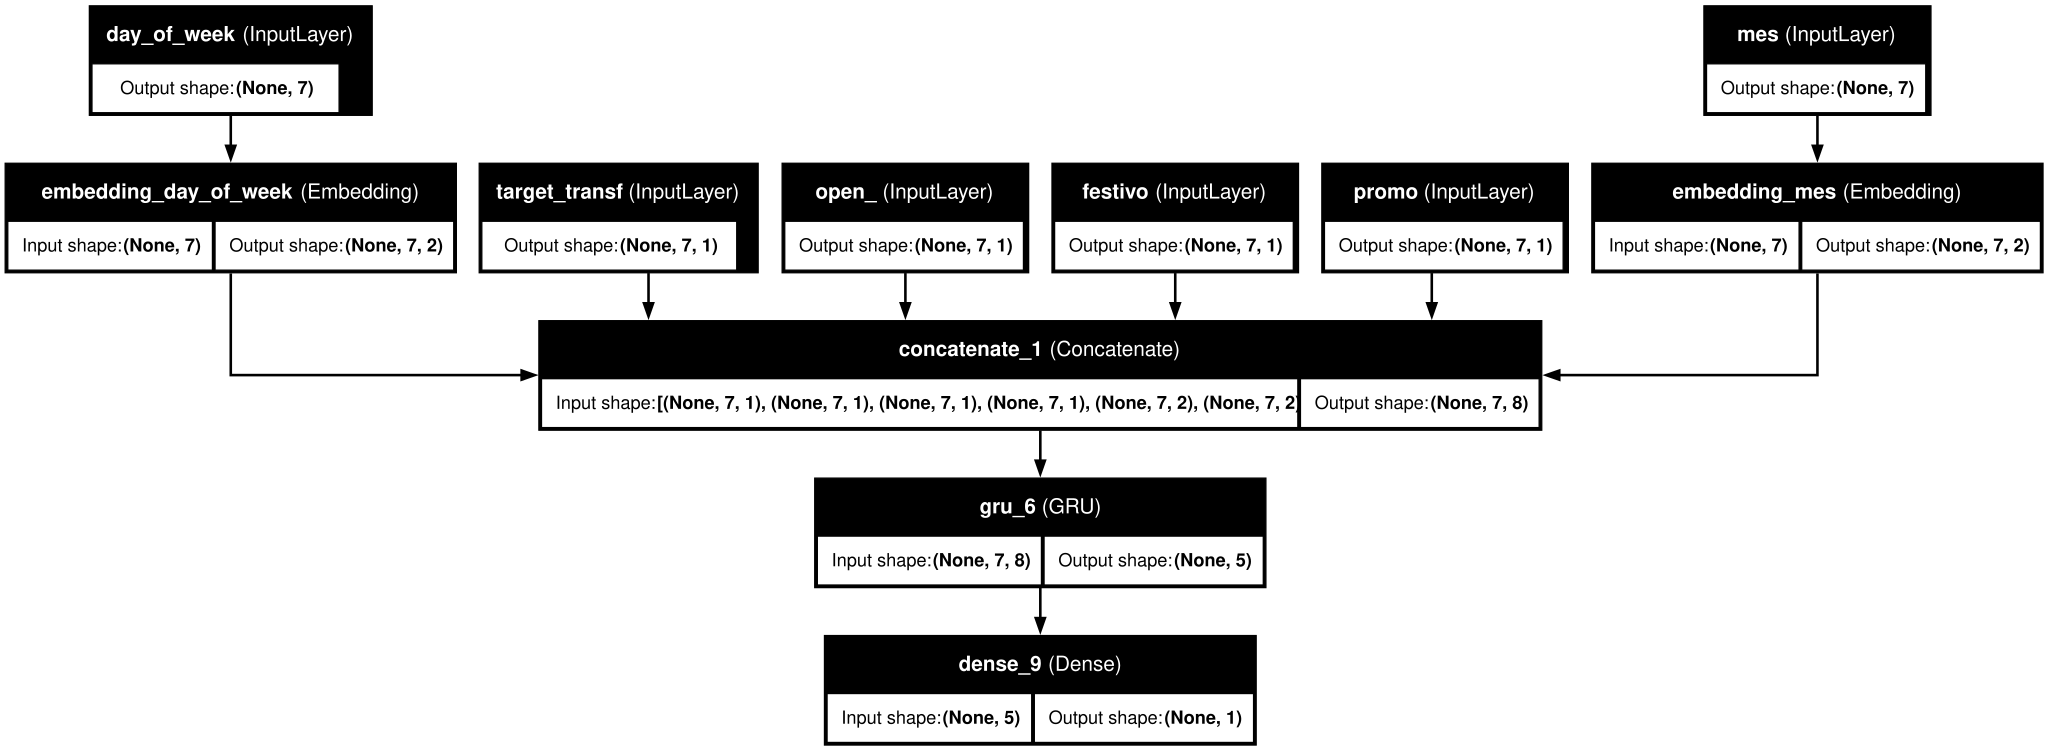

In [225]:

from IPython.display import SVG
from keras.utils import model_to_dot
display(SVG(model_to_dot(model,show_shapes=True).create(prog='dot', format='svg')))

In [226]:
from os import getcwd
current_path=getcwd().replace("\\", "/")
model_store1_embeddings_path=current_path+"/Store_1/Tercer_modelo_embeddings.keras"

In [227]:
from keras.callbacks import ModelCheckpoint
checkpoint=ModelCheckpoint(filepath=model_store1_embeddings_path, monitor="val_loss", save_best_only=True, verbose=2)

In [228]:
X_train={
    "target_transf": X_0_train,
    "open_": X_1_train,
    "festivo": X_2_train,
    "promo": X_3_train,
    "day_of_week": X_4_train,
    "mes": X_5_train,
}

X_val={
    "target_transf": X_0_val,
    "open_": X_1_val,
    "festivo": X_2_val,
    "promo": X_3_val,
    "day_of_week": X_4_val,
    "mes": X_5_val,
}

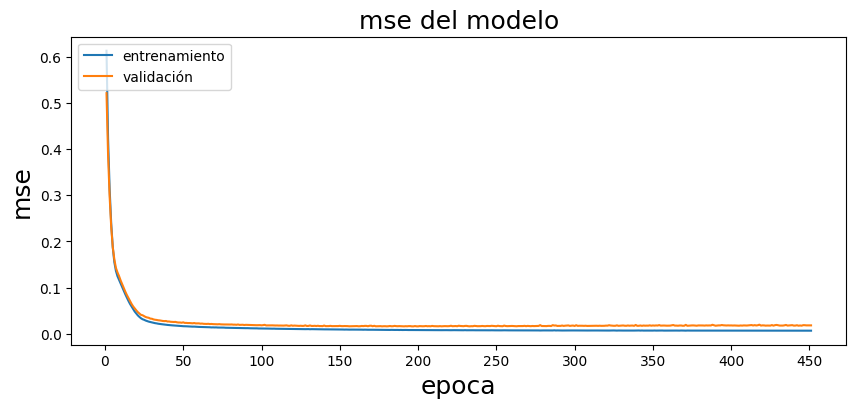


Epoch 1: val_loss did not improve from 0.01597

Epoch 1: val_loss did not improve from 0.01597

Epoch 1: val_loss did not improve from 0.01597

Epoch 1: val_loss did not improve from 0.01597

Epoch 1: val_loss did not improve from 0.01597

Epoch 1: val_loss did not improve from 0.01597

Epoch 1: val_loss did not improve from 0.01597

Epoch 1: val_loss did not improve from 0.01597

Epoch 1: val_loss did not improve from 0.01597

Epoch 1: val_loss did not improve from 0.01597

Epoch 1: val_loss did not improve from 0.01597

Epoch 1: val_loss did not improve from 0.01597

Epoch 1: val_loss did not improve from 0.01597

Epoch 1: val_loss did not improve from 0.01597

Epoch 1: val_loss did not improve from 0.01597

Epoch 1: val_loss did not improve from 0.01597

Epoch 1: val_loss did not improve from 0.01597

Epoch 1: val_loss did not improve from 0.01597

Epoch 1: val_loss did not improve from 0.01597

Epoch 1: val_loss did not improve from 0.01597

Epoch 1: val_loss did not improve from 

In [229]:
from IPython.display import clear_output
batchsize=64
epocas=500
losses_train=[]
losses_val=[]

for e in range (epocas):
    history=model.fit(X_train, y_train, epochs=1, verbose=0, batch_size=batchsize, callbacks=checkpoint, validation_data=(X_val, y_val))
    losses_train.append(history.history["loss"])
    losses_val.append(history.history["val_loss"])

    if (e%50)==0:
        clear_output()
        grafica_entrenamiento(losses_train,losses_val)



In [236]:
X_test={
    "target_transf": X_0_test,
    "open_": X_1_test,
    "festivo": X_2_test,
    "promo": X_3_test,
    "day_of_week": X_4_test,
    "mes": X_5_test,
}

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


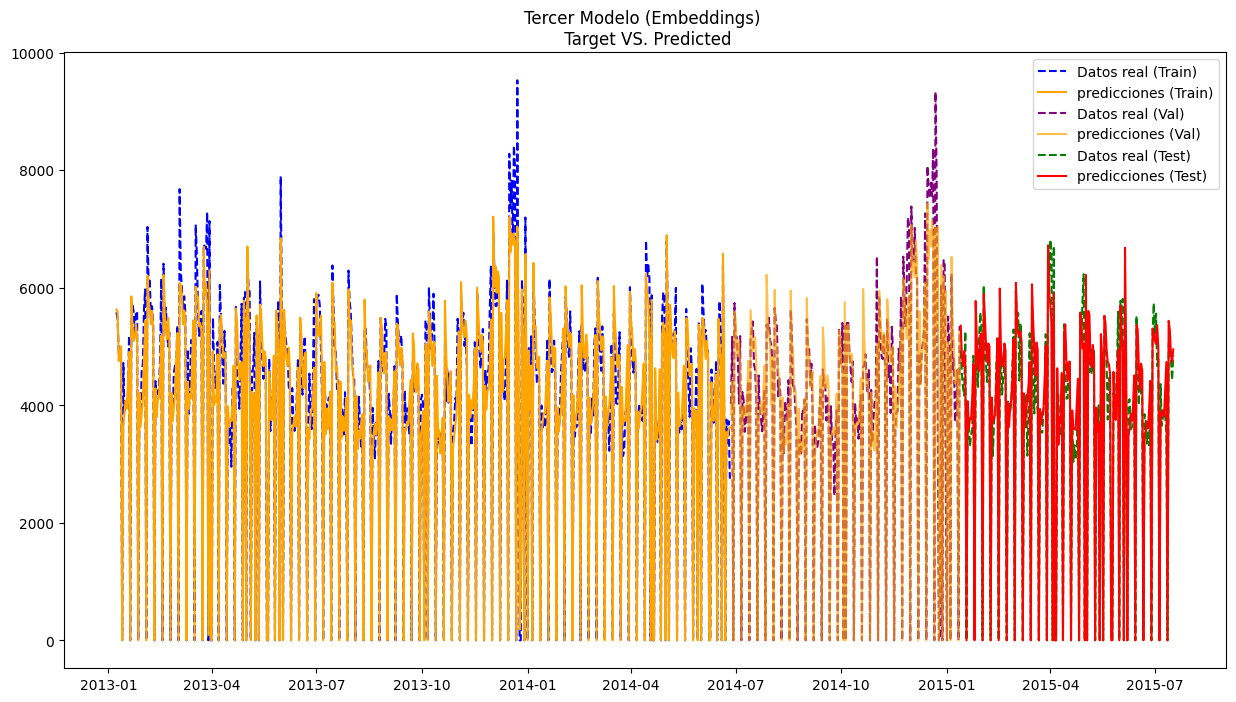

In [237]:
from keras.models import load_model

#Cagamos el modelo
model=load_model(model_store1_embeddings_path)

#Prediccion y transf Train
target_train_predicted_transf=model.predict(X_train)
target_train_predicted=inverse_transform(target_train_predicted_transf)

#Prediccion y transf Val
target_val_predicted_transf=model.predict(X_val)
target_val_predicted=inverse_transform(target_val_predicted_transf)

#Prediccion y transf Test
target_test_predicted_transf=model.predict(X_test)
target_test_predicted=inverse_transform(target_test_predicted_transf)


#Training plot
plt.figure(figsize=(15,8))
plt.plot(fechas_train, target_train, label="Datos real (Train)", linestyle="--", color="blue")
plt.plot(fechas_train, target_train_predicted, label="predicciones (Train)", color="orange")
#Val plot
plt.plot(fechas_val, target_val, label="Datos real (Val)", linestyle="--", color="purple")
plt.plot(fechas_val, target_val_predicted, label="predicciones (Val)", color="orange", alpha=0.7)
#Test plot
plt.plot(fechas_test, target_test, label="Datos real (Test)", linestyle="--", color="green")
plt.plot(fechas_test, target_test_predicted, label="predicciones (Test)", color="red")
plt.legend(loc="upper right")
plt.title("Tercer Modelo (Embeddings) \n Target VS. Predicted")
plt.show()

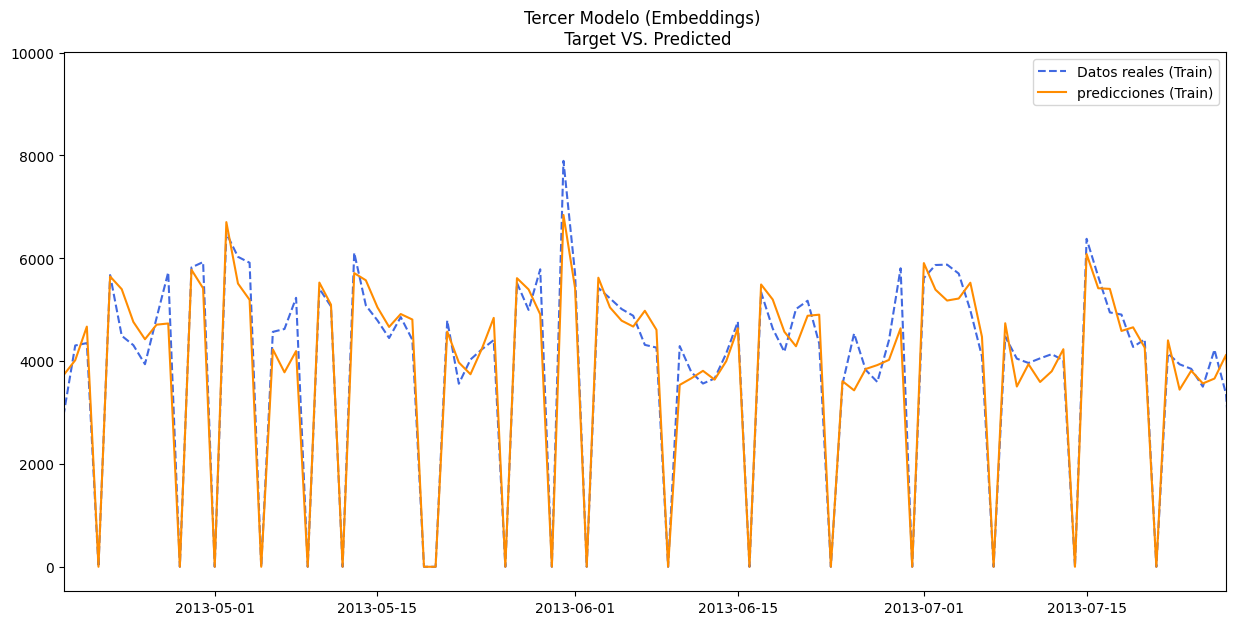

In [246]:
#Hacemos zoom en datos de entrenamiento para un analisis correcto
plt.figure(figsize=(15,7))
plt.plot(fechas_train, target_train, "--", c="royalblue", label="Datos reales (Train)")
plt.plot(fechas_train, target_train_predicted, c="darkorange", label="predicciones (Train)")
plt.xlim([fechas_train[100], fechas_train[200]])
plt.title("Tercer Modelo (Embeddings) \n Target VS. Predicted")
plt.legend();

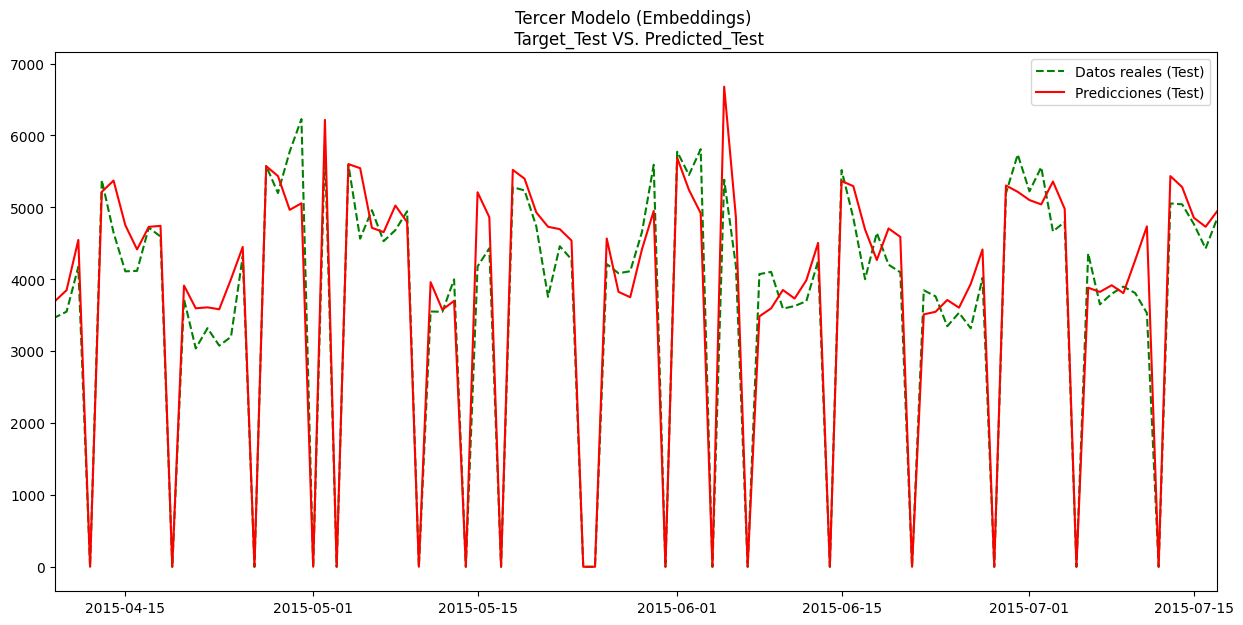

In [247]:
plt.figure(figsize=(15,7))
plt.plot(fechas_test, target_test, "--", c="green", label="Datos reales (Test)")
plt.plot(fechas_test, target_test_predicted, c="red", label="Predicciones (Test)")
plt.xlim([fechas_test[-100], fechas_test[-1]])
plt.title("Tercer Modelo (Embeddings) \n Target_Test VS. Predicted_Test")
plt.legend();

In [253]:
from sklearn.metrics import r2_score as R2
R2_score_train_modelo3=R2(target_train, target_train_predicted)
print(f"Coeficiente de determinación R2 para Train: {R2_score_train_modelo3:.2f} ")

Coeficiente de determinación R2 para Train: 0.95 


In [254]:
R2_score_test_modelo3=R2(target_test, target_test_predicted)
print(f"Coeficiente de determinación R2 para Test: {R2_score_test_modelo3:.2f} ")

Coeficiente de determinación R2 para Test: 0.94 


###Conclusion: A pesar de haber utilizado un tercer modelo en el que las variables categóricas con más de dos clases fueron tratadas mediante embeddings dentro de la propia arquitectura de la red recurrente, utilizando Input y concatenate de Keras, no se observó una mejora significativa frente al modelo con variables exógenas procesadas mediante One-Hot Encoding para las variables mes y day_of_week.
El coeficiente de determinación en el conjunto de prueba pasó de 0.93 a 0.94 al utilizar el modelo con embeddings. Si bien existe una leve mejora, esta diferencia no parece justificar el incremento en complejidad del modelo ni la necesidad de definir múltiples entradas y capas de embedding dentro de la red.
Por lo tanto, se considera que el modelo basado en One-Hot Encoding sigue siendo una alternativa suficientemente robusta, más simple de implementar, más fácil de interpretar y más conveniente para este caso. En consecuencia, no se considera necesario utilizar el modelo con embeddings como solución final.